# Notes from a leakage-conscious, physics-aware trajectory study

The job is to continue TVT past the observed part of a directional well, using its geometry, gamma-ray log, and a reference type well. My first validation split was way too easy; nearby, near-identical wells could end up on opposite sides of a fold without anyone noticing. I swapped it for a graph-based split that keeps every connected geological group together instead.

The model grew out of two trajectory estimates; a particle filter and a GeoHMM. HGRG controls how far their agreement is allowed to pull a protected baseline, while the state-space and boundary terms handle smaller corrections on top. I ran the full clean-room version across all 320 training wells. The similarity graph came out to 243 components, which I split into two non-overlapping 160-well panels.

One distinction matters throughout this notebook: the code here reruns the clean-room graph and the audited 121-feature calculation, but it doesn't recreate the exact 9.091 submission without the external model files that run used. I keep those two lineages separate everywhere below.

> To rerun this notebook on Kaggle, attach the companion dataset built from this folder. The saved notebook reads fine on its own, but the code cells load `src/`, `evidence/`, and selected files under `artifacts/`.

In [1]:
from pathlib import Path
import inspect
import json
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

def find_project_root():
    candidates = [Path.cwd()]
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(sorted(path for path in kaggle_input.glob("*") if path.is_dir()))
        candidates.extend(sorted(path for path in kaggle_input.glob("*/*") if path.is_dir()))

        archives = sorted(kaggle_input.glob("**/rogii_portfolio_companion.zip"))
        if archives:
            extracted = Path("/kaggle/working/rogii_portfolio_companion")
            marker = extracted / "evidence/reproduction_summary.json"
            if not marker.exists():
                extracted.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(archives[0]) as bundle:
                    for member in bundle.infolist():
                        member_path = Path(member.filename)
                        if member_path.is_absolute() or ".." in member_path.parts:
                            raise ValueError(f"Unsafe path in companion archive: {member.filename}")
                    bundle.extractall(extracted)
            candidates.insert(0, extracted)

    for candidate in candidates:
        if (candidate / "evidence/reproduction_summary.json").exists() and (candidate / "src/rogii_portfolio").is_dir():
            return candidate
    raise FileNotFoundError("Attach the ROGII portfolio dataset or run this notebook from the project folder.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))
from rogii_portfolio.artifacts import verify_manifest
from rogii_portfolio.features import SAFE_FEATURES
from rogii_portfolio.historical_features import HISTORICAL_ORIGINAL_BUILDER_SHA256
from rogii_portfolio.hgrg import apply_hgrg
from rogii_portfolio.meta_state import apply_meta_state

summary = json.loads((ROOT / "evidence/reproduction_summary.json").read_text())
manifest = verify_manifest(ROOT)
lineage = json.loads((ROOT / "evidence/method_lineage.json").read_text())

def load_optional(path):
    path = ROOT / path
    return json.loads(path.read_text()) if path.exists() else None

primary160 = load_optional("artifacts/realdata_nested_160/evidence/reproduction_summary.json")
confirmation160 = load_optional("artifacts/realdata_nested_160_confirmation/evidence/reproduction_summary.json")
frozen_confirmation = load_optional("artifacts/realdata_nested_160_confirmation/frozen_policy_evaluation.json")
regret_router = load_optional("artifacts/realdata_nested_160/regret_router/summary.json")
meta_shrinkage = load_optional("artifacts/realdata_nested_160_confirmation/posthoc_meta_shrinkage.json")
graph_audit = load_optional("artifacts/realdata_nested_160/graph_audit/cross_partition_diagnostics.json")
deployment_audit = load_optional("evidence/deployment_smoke_audit.json")
print("Project data loaded.")
print(f"Checked {len(manifest['artifacts'])} saved artifacts")
print(f"Validation contract: {summary['contract']}")


Project data loaded.
Checked 8 saved artifacts
Validation contract: fully_nested_geological_component_cv_plus_single_untouched_holdout


In [2]:
executive = pd.DataFrame([
    ["Data", summary["wells"], summary["components"]],
    ["Development", summary["development_wells"], summary["development_components"]],
    ["Untouched holdout", summary["holdout_wells"], summary["holdout_components"]],
], columns=["Partition", "Wells", "Geological components"])
display(Markdown("**Deterministic CI smoke (not a score estimate)**"))
display(executive)
display(pd.DataFrame({
    "Outer OOF RMSE": summary["outer_oof_rmse"],
    "Untouched holdout RMSE": summary["untouched_holdout_rmse"],
}).loc[["pf", "incumbent", "hgrg", "meta_state", "prefix_boundary", "sequential_final", "nested_stack"]])


**Deterministic CI smoke (not a score estimate)**

,Partition,Wells,Geological components
0,Data,18,9
1,Development,14,7
2,Untouched holdout,4,2


,Outer OOF RMSE,Untouched holdout RMSE
pf,0.861252,0.551364
incumbent,0.635418,0.438344
hgrg,0.626881,0.434970
meta_state,0.614281,0.467684
prefix_boundary,0.305810,0.538140
sequential_final,0.322901,0.502000
nested_stack,0.304900,0.491838


## 1. Why I gave up on well-level splits

A well ID isn't an independent geological unit, so splitting by well ID alone doesn't buy you much. Instead, I build a graph where wells are vertices and edges represent strong XY proximity or high GR/type-well similarity, then run validation splits on connected components rather than rows or IDs. That directly targets the failure mode I was actually worried about: a model quietly recognizing local structure it picked up from a neighboring training well.

I build the graph before fitting anything. Each run-level holdout gets chosen before that run's models are trained, and its labels never touch feature construction, policy selection, or stack weights. That said, this doesn't erase my adaptive research history; I've looked at some of these panels more than once; so I call reused panels transfer panels rather than pretending they're pristine confirmations.

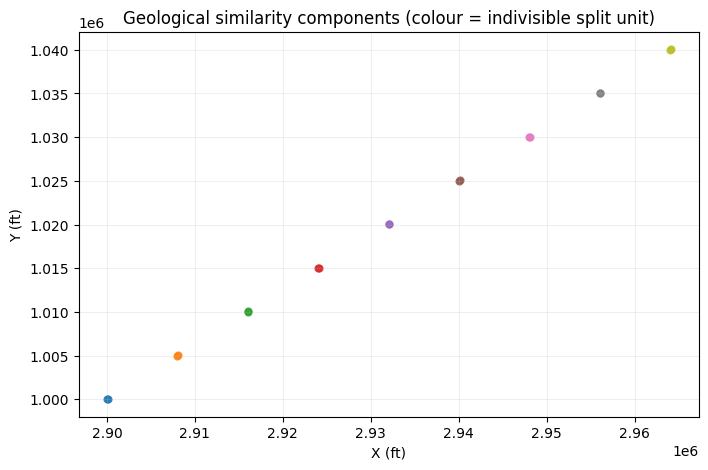

In [3]:
components = pd.read_csv(ROOT / "evidence/geological_components.csv")
fig, ax = plt.subplots(figsize=(8, 5))
for component, group in components.groupby("component"):
    ax.scatter(group.x, group.y, s=24, alpha=.75)
ax.set_title("Geological similarity components (colour = indivisible split unit)")
ax.set_xlabel("X (ft)"); ax.set_ylabel("Y (ft)"); ax.grid(alpha=.2)
plt.show()


## 2. Keeping the scored pipeline and this rebuild separate

The historical scored lineage looked like this:

```text
incumbent baseline->HGRG->Meta-State->Prefix-Boundary->conditional GeoHMM shape
```

I used the 121-feature nonlinear retrain and the nested residual stack as controls; they were never part of the historical 9.091 graph, and the 40-, 80-, and 160-well results don't add up cleanly since their parents and populations differ.

The executable nested graph here runs on a **retrained clean parent**, not the historical incumbent. The real incumbent also had SP45/beam selection, robust polynomial projection, visible-prefix calibration, contact logic, DTRT, and some external learned packages baked in. HGRG and conditional shape are formula-faithful to the original; the structural Meta-State and fixed-window boundary blocks here are clean-room analogues instead. The only way an exact expert path gets in is through a SHA-verified historical-artifact adapter.

The actual implementation lives in `src/rogii_portfolio`. `make reproduce` runs the tests and the clean-room graph before rebuilding this notebook. The external Kaggle artifacts aren't bundled here; they're listed separately.

In [ ]:
implementation = pd.read_csv(ROOT / "evidence/historical_stage_scores.csv")
display(implementation)
print("Scored lineage:", "->".join(lineage["scored_lineage"]))
print("Separate controls:", ", ".join(lineage["separate_research_controls"]))
fidelity = pd.DataFrame([
    ["Historical 121 features", "source-hash verified"],
    ["PF / no-prior GeoHMM", "formula-faithful research implementation"],
    ["HGRG / conditional shape", "formula-faithful overlay"],
    ["Scored incumbent", "external artifact required"],
    ["Structural Meta-State", "clean-room analogue"],
    ["Prefix-Boundary", "clean-room fixed-window analogue"],
], columns=["Block", "Status in this repository"])
display(fidelity)


,contract,stage,rmse_ft,gain_vs_immediate_parent_ft,evidence_role
0,Dev40 discovery,PF8,7.507195,0.000000,discovery control
1,Dev40 discovery,PF8 + 20% GeoHMM,6.577537,0.929658,discovery signal only
2,Exact80 repeated transfer,detector-off parent,7.829921,0.000000,common-parent ladder
3,Exact80 repeated transfer,HGRG,7.500639,0.329282,common-parent ladder
4,Exact80 repeated transfer,Meta-State,7.432400,0.068239,common-parent ladder
5,Exact80 repeated transfer,Prefix-Boundary,7.414100,0.018300,common-parent ladder
6,Exact80 repeated transfer,conditional shape composition,7.398600,0.015500,reused panel exploratory composition
7,Exact773 component OOF,FAST-SAFE nonlinear raw,13.654956,0.000000,separate nonlinear control
8,Exact773 component OOF,FAST-SAFE + frozen CHRRC,13.606509,0.048447,separate nonlinear control
9,Nonlinear code run,visible partition,11.223000,NaN,single platform observation


Scored lineage: incumbent baseline → Hierarchical Geology Regret Gate → Meta-State → Prefix-Boundary → conditional stride-6 GeoHMM shape
Separate controls: 121-feature FAST-SAFE nonlinear retrain, nested convex residual stack, optimizer/epoch/decoder sweep


,Block,Status in this repository
0,Historical 121 features,source-hash verified
1,PF / no-prior GeoHMM,formula-faithful research implementation
2,HGRG / conditional shape,formula-faithful overlay
3,Scored incumbent,external artifact required
4,Structural Meta-State,clean-room analogue
5,Prefix-Boundary,clean-room fixed-window analogue


### Where the constants actually came from

Honestly, this pipeline has more constants than I'd choose if I were designing it fresh. Some came from the historical baseline, some were fit inside outer training folds, and others are just movement caps I picked. The table below records where each one came from, so a reproducible decimal doesn't get mistaken for a measured physical constant.

| Block | Important constants | Provenance | How I use it |
|---|---|---|---|
| Historical incumbent | legacy mixtures, SP45/beam, projection, contact/DTRT | external scored lineage | exact only with pinned artifact |
| Retrained clean parent | 0.30 Ridge + 0.70 PF; 0.00425 HGB cap | fixed clean-room heuristic | defines this validation parent |
| HGRG | beta 0.5; 250-ft ramp; 2.5/10-ft caps | frozen project policy | same-contract block result |
| Clean Meta-State | 0.65/0.25/0.10; 0.32 coefficient; 5/10-ft caps | clean-room analogue | no historical hidden attribution |
| Prefix-Boundary | tau/lookback 256; 2.5/10-ft caps | clean-room analogue | same-contract result |
| Conditional shape | 6.41825; 0.0090056; 0.25; 0.75/2.5-ft caps | frozen prediction-only policy | transfer evidence only |
| Expanded stack | learned convex weights | primary outer OOF | complementary components decide promotion |

## 3. PF and GeoHMM: two takes on the same trajectory

The particle filter tracks structural position $U=TVT+Z$ and incidence rate. For particle $i$, a simplified update looks like

$$
U_t^{(i)} = U_{t-1}^{(i)} + r_t^{(i)}\Delta MD_t + \epsilon_t^{(i)},
\qquad
w_t^{(i)} \propto w_{t-1}^{(i)}
\exp\!\left[-\frac{(GR_t-g(TVT_t^{(i)}))^2}{2\sigma_{GR}^2}\right].
$$

GeoHMM instead works off a 0.5-ft TVT grid and 25 slope states, with robust GR emissions and checkpointed forward–backward inference. Neither expert ever sees coordinates, neighboring-well labels, or suffix TVT. Their disagreement is a genuinely useful uncertainty signal, but it's worth being clear that they're **distinct and correlated**, not independent; they're not two unrelated opinions.

## 4. HGRG: a bounded update between PF and GeoHMM

HGRG moves the parent coordinate-wise toward the PF–GeoHMM bridge, under nonnegative shrinkage and hard movement caps.

$$
Q=P+\beta(H-P),\qquad d=Q-B,
$$

$$
u=\frac{\operatorname{RMS}(H-P)}{\max(\operatorname{RMS}(d),\varepsilon)},
\qquad
p=\frac{\langle d,R-B\rangle}{\max(\langle d,d\rangle,\varepsilon)},
$$

$$
\rho=u\exp[-2\operatorname{clip}(p,-1,1)],\qquad
g=0.25+0.75\min(1,\rho^{-2}),
$$

$$
\widehat{TVT}=B+\operatorname{clip}\!\left(
\operatorname{clip}\!\left(\frac{h}{250},0,1\right)
g\min\!\left(0.5,\frac{2.5}{\max(\operatorname{RMS}(d),\varepsilon)}\right)d,
-10,10\right).
$$

The simplest thing to compare this against is just a fixed PF/GeoHMM blend. HGRG goes further by using normalized disagreement, directional consensus, and regret caps; though it can still fail if every expert happens to share the same misspecification.

Runtime and memory after PF/HMM are both $O(N)$ per well, for what it's worth.

In [5]:
source = inspect.getsource(apply_hgrg)
print("Executable HGRG implementation (first 45 lines):")
print("\n".join(source.splitlines()[:45]))


Executable HGRG implementation (first 45 lines):
def apply_hgrg(
    *,
    base: np.ndarray,
    ridge: np.ndarray,
    pf: np.ndarray,
    hmm: np.ndarray,
    horizon: np.ndarray,
    policy: HGRGPolicy = HGRGPolicy(),
) -> tuple[np.ndarray, dict[str, float]]:
    """Move the base trajectory toward the PF/HMM bridge under movement caps."""
    base, ridge, pf, hmm, horizon = map(lambda x: np.asarray(x, float), (base, ridge, pf, hmm, horizon))
    if len({len(base), len(ridge), len(pf), len(hmm), len(horizon)}) != 1:
        raise ValueError("HGRG inputs are not aligned")
    q = pf + policy.beta * (hmm - pf)
    direction = q - base
    direction_rms = rms(direction)
    dispersion = rms(hmm - pf)
    relative_dispersion = dispersion / max(direction_rms, 1e-12)
    projection = float(np.dot(direction, ridge - base) / max(np.dot(direction, direction), 1e-12))
    risk = relative_dispersion * np.exp(-policy.consensus_strength * np.clip(projection, -1.0, 1.0))
    raw_gate = min(1.0, (

## 5. Meta-State, reimplemented

I fit an RBF surface using only outer-training wells. A target well uses its visible prefix to estimate a vertical offset and a rolling-origin error; it never gets to see its own suffix TVT or formation label.

For the PF, HMM, and structural observations, I build a correlated covariance matrix $\Sigma$. Any negative generalized least-squares weights get clipped before normalizing:

$$
\widetilde w=\Sigma^{-1}\mathbf 1,\qquad
w_i=\frac{\max(\widetilde w_i,0)}{\sum_j\max(\widetilde w_j,0)}.
$$

That fused observation then feeds into a constant-acceleration state model with position, slope, and curvature,

$$
x_{t+1}=
\begin{bmatrix}1&\Delta&\tfrac12\Delta^2\\0&1&\Delta\\0&0&1\end{bmatrix}x_t+\eta_t,
$$

followed by a Rauch–Tung–Striebel backward pass. A prediction-time PF/HMM-to-state dispersion ratio scales the bounded move coming out of HGRG. So really, the end result is a state-space fusion model built around a single spatial observation.

The closest thing to compare it against is plain independent inverse-variance averaging plus a generic smoother. It's most likely to fail in sparse or extrapolative XY regions, and prefix rolling error only partially guards against a biased formation surface. I'll flag that this isn't byte-identical to the scored block; the historical path also used a q25 anchor, a horizon ramp, a 3-ft pre-consensus projection, and different structural transport rules.

## 6. Small corrections right at the prefix boundary

For Prefix-Boundary, I extrapolate the last visible slope of $U=TVT+Z$, then let the correction decay with horizon:

$$
\Delta U(h)=\operatorname{clip}\left(e^{-h/256}[U_0+s h-(B(h)+Z(h))],-10,10\right).
$$

That move gets projected to a 2.5-ft RMS budget. It helps with continuity, but it can fail if the true dip changes abruptly right after the prefix ends. The clean-room code just fixes a 256-ft lookback; the historical branch actually picked among 64/128/256/512/1024 ft based on visible-prefix rolling error.

For the shape correction, let $d=H_{stride6}-P$. I remove the well mean before projecting, so only the local shape survives:

$$
A=\operatorname{RMS}(d),\quad
S=\frac{\operatorname{RMS}(\Delta d)}{\max(A,\varepsilon)},\quad
g=\frac{1}{1+(A/6.41825)^2}\frac{S}{S+0.0090056}.
$$

The raw move is $0.25g(d-\bar d)$, projected to a 0.75-ft RMS and a 2.5-ft row cap. I call this "mean removal before projection" specifically because row clipping can shift the mean right back again if you're not careful about the order.

## 7. The 121-feature branch and the nested stack

My readable clean-room builder predicts a residual from PF using exactly 121 local-observable features; geometry, GR derivatives/rolling windows, type-well residual banks, visible-prefix calibration, and target-free PF/HMM paths. Any unknown feature name fails closed. No global spatial interpolation, no dense neighbors, no well identity, no suffix target values.

For comparison, I also kept the audited historical 121-feature version around. It preserves PF600/ANCC600, seven beams, multi-scale NCC, stable per-well seeds, and float32 output. I pin its source identity with the original notebook-cell SHA-256, and a suffix-truth poison test confirms its output stays byte-invariant. The formulas are different between the two, so I keep this builder separate even in places where the column names happen to match.

The stack itself is fit from **inner-OOF** expert moves, with weights constrained to $w_k\ge0$ and $\sum_k w_k\le1$; whatever mass is left over just stays on the parent:

$$
\min_w \sum_i q_i\left(y_i-B_i-\sum_k w_k(E_{ik}-B_i)\right)^2+\lambda\lVert w\rVert_2^2.
$$

The row weights $q_i$ balance out the geological components. I'm using this stack as a control here, not as an explanation for the historical hidden score.

In [6]:
families = pd.Series([name.split("_")[0] if "_" in name else ''.join(filter(str.isalpha, name)) for name in SAFE_FEATURES]).value_counts()
print("Feature count:", len(SAFE_FEATURES))
print("Historical builder source SHA-256:", HISTORICAL_ORIGINAL_BUILDER_SHA256)
display(pd.DataFrame({"feature": SAFE_FEATURES}).head(20))
display(pd.DataFrame({"family_token": families.index, "count": families.values}).head(15))


Feature count: 121
Historical builder source SHA-256: 500c9255b3bfd2268c8bb2e9be1a4025f0aa01d3483e67b4e28fa31e1d5d2c2c


,feature
0,beam_cons_d
1,beam_loose_d
2,beam_mean_d
3,beam_med_d
4,beam_mid_d
5,beam_sm5_d
6,beam_std_d
7,beam_stiff_d
8,beam_vcons_d
9,beam_vloose_d


,family_token,count
0,tdsc,11
1,tda,11
2,tdbc,11
3,tdpf,11
4,beam,10
5,gr,7
6,pf,6
7,slp,5
8,sc,4
9,grs,4


## 8. Nested validation, starting with a quick sanity check

For each outer fold, I refit the 121-feature estimators and the structural RBF from outer-training components only. Inner component OOF predictions fit the stack. The fold-frozen graph then predicts on the outer validation components. Only once every outer prediction exists do I freeze one development stack, refit it on all development components, and evaluate the run-level holdout exactly once.

PF/HMM and target-local features can be cached inside this split since they don't learn across wells. The model-facing `PreparedWell` dataclass has no truth field at all, and official mode flatly refuses to reconstruct a broken prefix from truth. None of the caching crosses fold boundaries.

The synthetic run below is really just a wiring check; its holdout only has two components, and a few overlays actually make it worse. That's exactly why I moved the main validation over to the full official-data graph instead of trusting this toy version.

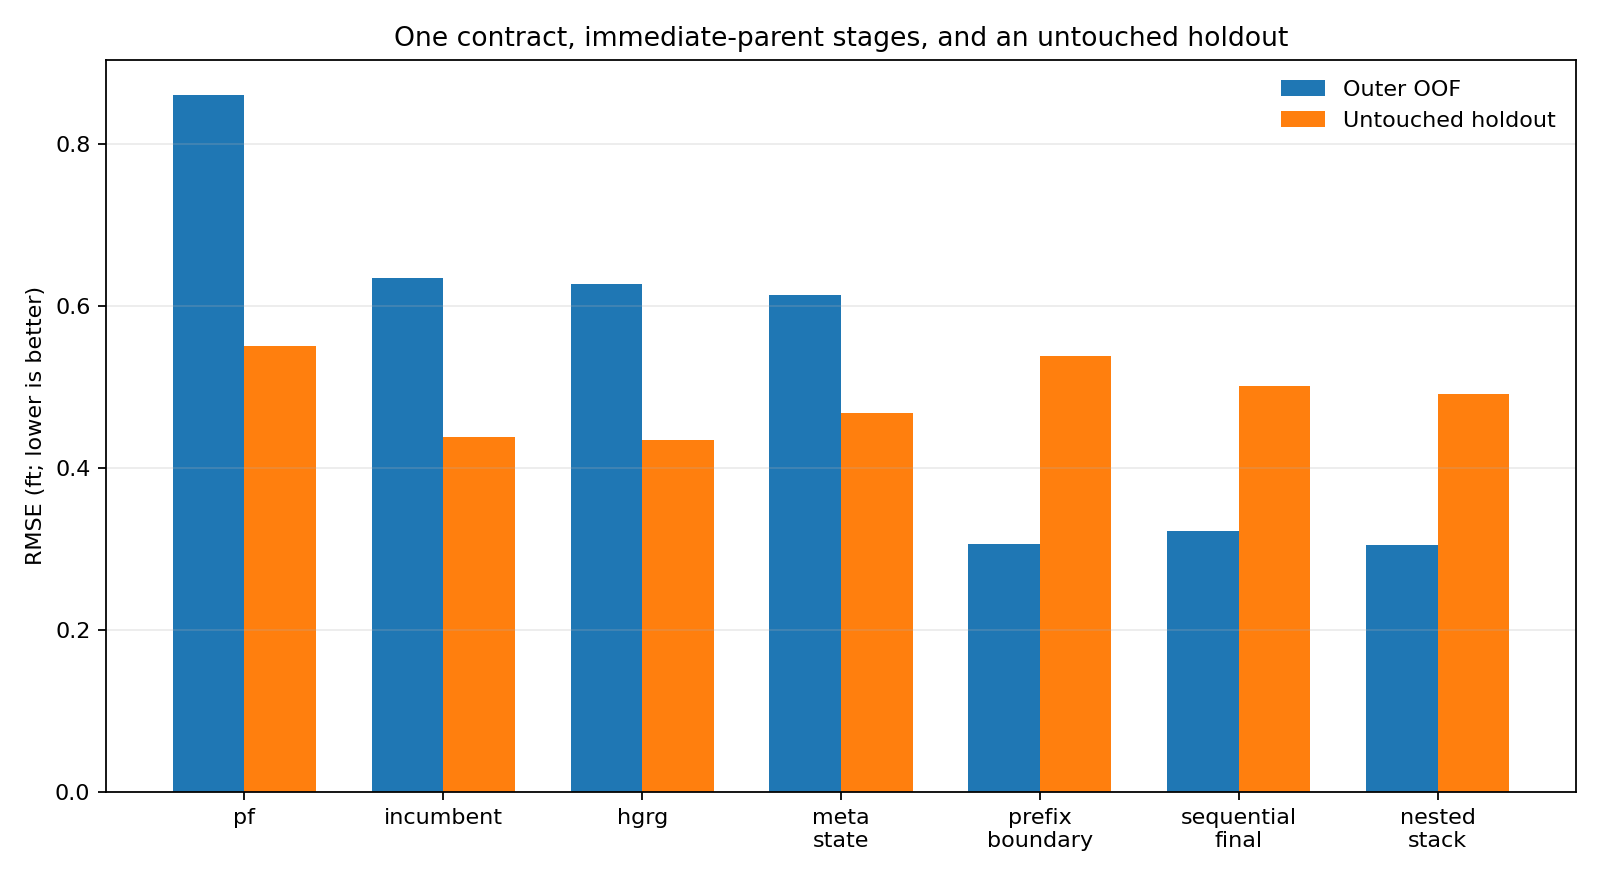

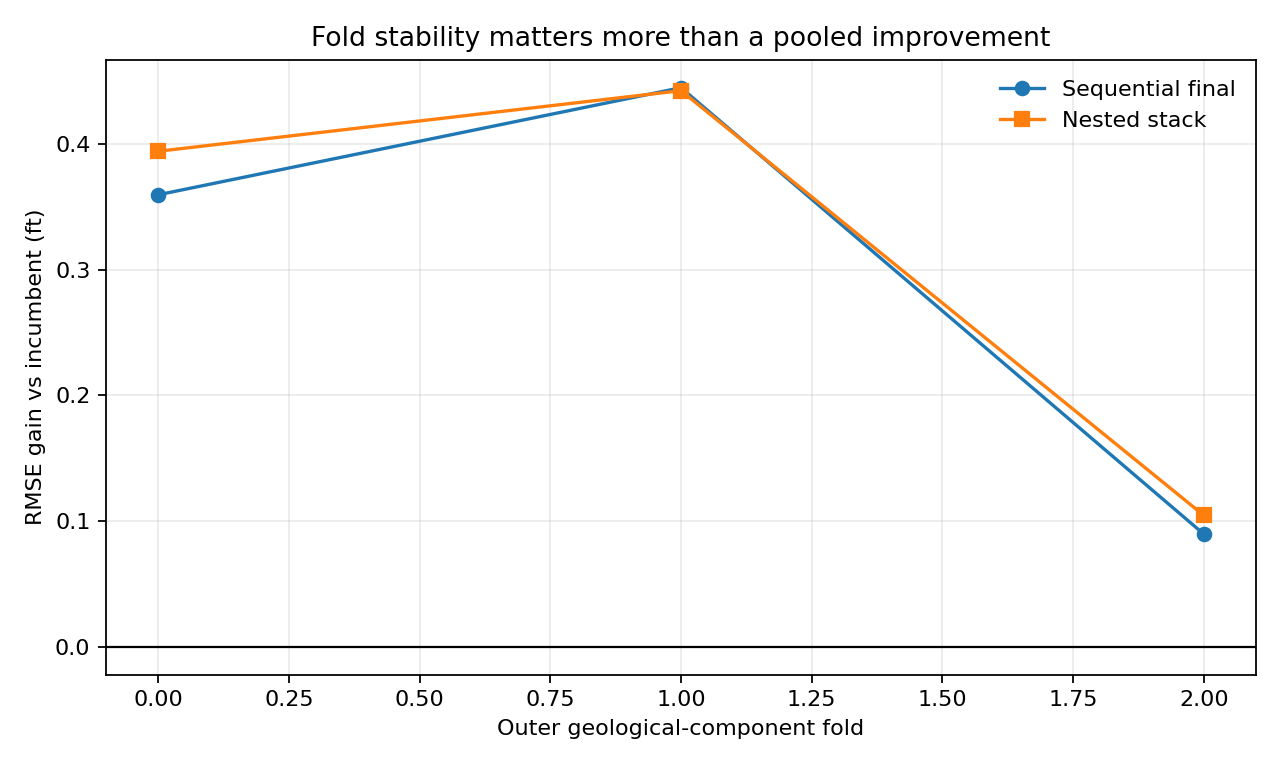

In [7]:
display(Image(filename=str(ROOT / "evidence/rmse_by_stage.png")))
display(Image(filename=str(ROOT / "evidence/outer_fold_gains.png")))


### An 18-well integration check

I also ran the same graph on 18 official raw training wells with compute deliberately turned way down (2 PF seeds × 32 particles, stride-24 GeoHMM). This is just checking that CSV discovery, the visible-prefix contract, feature construction, nested fitting, and structural inference all behave correctly on real data shapes. It is **not** a leaderboard estimate; the subset is tiny, the holdout only has four components, the compute doesn't match the full policy, and the component graph isn't built over the whole competition universe.

In [8]:
real_path = ROOT / "artifacts/realdata_smoke/evidence/reproduction_summary.json"
if real_path.exists():
    real = json.loads(real_path.read_text())
    display(pd.DataFrame({
        "Outer OOF": real["outer_oof_rmse"],
        "Subset holdout": real["untouched_holdout_rmse"],
    }).loc[["incumbent", "hgrg", "meta_state", "prefix_boundary", "sequential_final", "nested_stack"]])
    print("Integration-only holdout components:", real["holdout_components"])
else:
    print("Run `make realdata-smoke DATA_ROOT=...` to populate this optional check.")


,Outer OOF,Subset holdout
incumbent,13.139736,24.021825
hgrg,12.937457,23.190744
meta_state,12.590120,23.060901
prefix_boundary,12.538964,23.052924
sequential_final,12.508629,23.026932
nested_stack,12.524582,23.026932


Integration-only holdout components: 4


## 9. The 320-well experiment

First I build the similarity graph over all 320 official training wells. At my frozen thresholds, that comes out to 243 connected components. I then sample **whole components** into a primary 160-well panel, and the remaining 160 wells form a component-disjoint confirmation panel. Both panels run the same 5-outer × 3-inner graph, with PF/HMM compute turned down.

That 243-component count is sensitive to the graph thresholds I picked, so I report threshold sensitivity below rather than treat it as a fixed number.

,Primary outer OOF,Primary run holdout
incumbent,15.555088,14.543160
ridge,13.162938,9.930971
nonlinear,16.247701,12.669466
hgrg,14.912065,13.926433
meta_state,14.959264,14.003731
prefix_boundary,14.931953,13.983244
sequential_final,14.899251,13.950361
nested_stack,14.900047,13.950361


Graph scope: 320 wells / 243 components; evaluated: 160 wells / 119 components


,ci95_high,ci95_low,components,draws,gain_mean,probability_positive
nested_stack_vs_incumbent,1.036993,0.118312,23.0,2000.0,0.588823,0.989
sequential_final_vs_incumbent,1.024476,0.129025,23.0,2000.0,0.596228,0.993


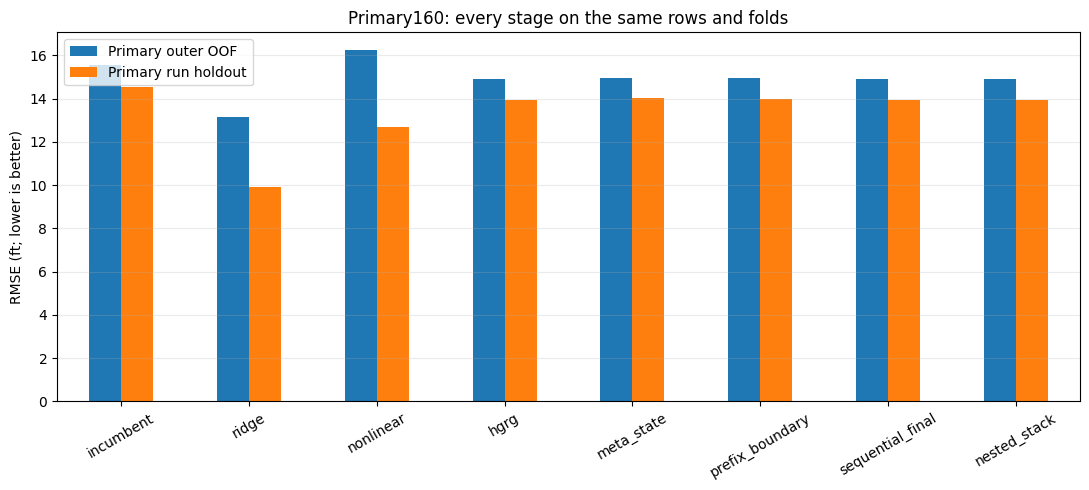

,value
base_edges,78
cross_partition_max_gr_correlation,0.793725
cross_partition_max_typewell_correlation,0.94209
cross_partition_min_distance_ft,1166.804988
cross_partition_pairs,10634
interpretation,These are diagnostics conditional on the chose...
selected_components,119
selected_wells,160
thresholds,"{'gr_similarity_threshold': 0.95, 'similarity_..."
universe_components,243


,spatial_radius_ft,similarity_threshold,components,largest_component_wells,multiwell_components
0,500.0,0.93,278,3,38
1,500.0,0.95,287,3,31
2,500.0,0.97,289,3,29
3,1000.0,0.93,234,5,68
4,1000.0,0.95,243,3,72
5,1000.0,0.97,245,3,70
6,1500.0,0.93,199,8,81
7,1500.0,0.95,208,4,89
8,1500.0,0.97,209,4,89


In [9]:
if primary160:
    stages = ["incumbent", "ridge", "nonlinear", "hgrg", "meta_state", "prefix_boundary", "sequential_final", "nested_stack"]
    primary_table = pd.DataFrame({
        "Primary outer OOF": primary160["outer_oof_rmse"],
        "Primary run holdout": primary160["untouched_holdout_rmse"],
    }).loc[stages]
    display(primary_table)
    print(
        f"Graph scope: {primary160['component_graph_scope_wells']} wells / "
        f"{primary160['component_graph_universe_components']} components; "
        f"evaluated: {primary160['wells']} wells / {primary160['components']} components"
    )
    display(pd.DataFrame(primary160["component_bootstrap"]).T)
    ax = primary_table.plot.bar(figsize=(11, 5), rot=30)
    ax.set_ylabel("RMSE (ft; lower is better)")
    ax.set_title("Primary160: every stage on the same rows and folds")
    ax.grid(axis="y", alpha=.25)
    plt.tight_layout(); plt.show()
else:
    print("Run `make realdata-nested-160 DATA_ROOT=...` to populate the primary panel.")

if graph_audit:
    display(pd.DataFrame([graph_audit]).T.rename(columns={0: "value"}))
    sensitivity_path = ROOT / "artifacts/realdata_nested_160/graph_audit/component_graph_sensitivity.csv"
    if sensitivity_path.exists():
        display(pd.read_csv(sensitivity_path))


### What the primary panel taught me

The sequential physics path improved on the clean incumbent for both the primary outer OOF and the run-level holdout. Ridge improved by a lot more, so I fit an expanded convex policy using only the primary outer OOF; the complementary panel was still completely untouched at that point. I'm reporting that fitted primary number as a selection statistic, not as genuine OOF performance, since I used it to choose the policy.

,arm,weight
0,incumbent,0.000000e+00
1,ridge,7.392587e-01
2,nonlinear,4.862899e-02
3,hgrg,1.909108e-14
4,meta_state,3.141371e-14
5,prefix_boundary,2.485535e-14
6,sequential_final,2.121123e-01


The fitted-policy RMSE is a selection statistic, not honest OOF for the stack. Promotion depends on the disjoint confirmation component panel.


contract,Complement160 outer OOF,Complement160 run holdout
model,,
expanded_frozen,14.308922,11.747253
incumbent,13.517732,15.476099
ridge_only,16.537633,11.372201
sequential_final,12.600008,14.817390


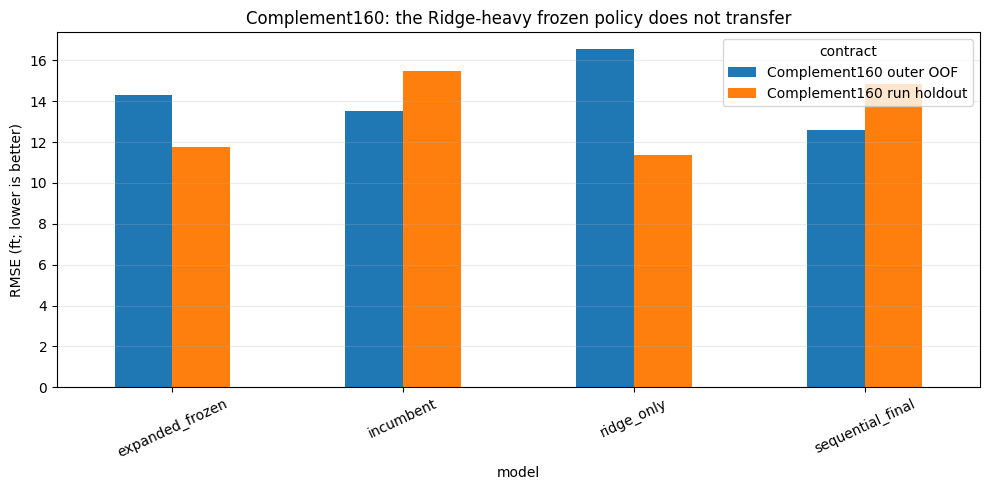

,ci95_high,ci95_low,components,draws,gain_mean,probability_positive
expanded OOF bootstrap,3.780948,-6.728582,100.0,5000.0,-0.473094,0.4116
ridge OOF bootstrap,3.754520,-11.565740,100.0,5000.0,-2.436846,0.3670


I did not keep the Ridge-heavy policy: it failed on complementary-component OOF.


In [10]:
policy_path = ROOT / "artifacts/realdata_nested_160/frozen_primary_policy.json"
if policy_path.exists():
    frozen_policy = json.loads(policy_path.read_text())
    display(pd.DataFrame({
        "arm": ["incumbent", *frozen_policy["arms"]],
        "weight": [frozen_policy["parent_weight"], *frozen_policy["weights"]],
    }))
    print(frozen_policy["claim_note"])

if frozen_confirmation:
    rows = []
    for contract_name, result in (
        ("Complement160 outer OOF", frozen_confirmation["confirmation_outer_oof"]),
        ("Complement160 run holdout", frozen_confirmation["confirmation_run_holdout"]),
    ):
        for model, score in result["rmse"].items():
            rows.append({"contract": contract_name, "model": model, "rmse_ft": score})
    confirmation_table = pd.DataFrame(rows)
    confirmation_pivot = confirmation_table.pivot(index="model", columns="contract", values="rmse_ft")
    display(confirmation_pivot)
    ax = confirmation_pivot.plot.bar(figsize=(10, 5), rot=25)
    ax.set_ylabel("RMSE (ft; lower is better)")
    ax.set_title("Complement160: the Ridge-heavy frozen policy does not transfer")
    ax.grid(axis="y", alpha=.25)
    plt.tight_layout(); plt.show()
    display(pd.DataFrame({
        "expanded OOF bootstrap": frozen_confirmation["confirmation_outer_oof"]["expanded_component_bootstrap"],
        "ridge OOF bootstrap": frozen_confirmation["confirmation_outer_oof"]["ridge_component_bootstrap"],
    }).T)
    endpoint = frozen_confirmation["confirmation_outer_oof"]
    if endpoint["gain_vs_incumbent"]["expanded_frozen"] <= 0:
        print("I did not keep the Ridge-heavy policy: it failed on complementary-component OOF.")
else:
    print("The complementary 160-well confirmation has not been materialized yet.")


In [11]:
folds = pd.read_csv(ROOT / "evidence/outer_fold_metrics.csv")
display(folds)
stack = summary["final_stack"]
display(pd.DataFrame({"weight": {"parent": stack["parent_weight"], **stack["weights"]}}))


,outer_fold,train_wells,valid_wells,train_components,valid_components,incumbent_rmse,sequential_final_rmse,nested_stack_rmse,stack_parent_weight,stack_hgrg,stack_meta_state,stack_prefix_boundary,stack_sequential_final
0,0,8,6,4,3,0.663482,0.304010,0.269418,0.121343,4.902914e-02,8.428724e-17,0.368234,0.461394
1,1,10,4,5,2,0.728386,0.283772,0.286117,0.039482,1.004280e-01,1.294407e-17,0.431814,0.428276
2,2,10,4,5,2,0.471473,0.381797,0.366922,0.000000,1.393819e-18,5.744333e-02,0.511941,0.430616


,weight
parent,7.795380e-02
hgrg,5.820527e-02
meta_state,1.834877e-17
prefix_boundary,4.148053e-01
sequential_final,4.490356e-01


## 10. Pairwise regret and a conformal-style abstention rule

Before the Primary160 run finished, I froze a second research control on the side. It predicts each expert's per-well MSE gain from target-free disagreement, movement, roughness, and horizon summaries, fit with component-cross-fitting. I subtract off a group-weighted absolute-residual quantile and just stick with the incumbent whenever every lower confidence score comes out non-positive:

$$
LCB_k(x)=\widehat{G}_k(x)-Q_q\left(\left|G_k-\widehat{G}^{OOF}_k\right|\right),
\qquad
k^*=\arg\max_k LCB_k(x).
$$

This is purely an abstention rule for expert regret; not a calibrated TVT interval. All it's really asking is: is moving away from the incumbent actually justified here?

In [12]:
if regret_router:
    display(pd.DataFrame({
        "metric": [
            "development incumbent", "development routed", "holdout incumbent",
            "holdout routed", "holdout abstention rate"
        ],
        "value": [
            regret_router["development_fallback_rmse"],
            regret_router["development_selected_rmse"],
            regret_router["holdout_fallback_rmse"],
            regret_router["holdout_selected_rmse"],
            regret_router["holdout_abstention_rate"],
        ],
    }))
    display(pd.DataFrame([regret_router["holdout_component_bootstrap"]]))
    print("Selected arms:", regret_router["holdout_selected_arm_counts"])
    print("The uncertainty signal was useful, but the simple sequential expert was still slightly better.")
else:
    print("Run the predeclared regret-router script after Primary160.")


,metric,value
0,development incumbent,15.555088
1,development routed,14.978283
2,holdout incumbent,14.543160
3,holdout routed,13.967432
4,holdout abstention rate,0.647059


,ci95_high,ci95_low,components,draws,gain_mean,probability_positive
0,1.005092,0.114834,23,2000,0.570395,0.9915


Selected arms: {'hgrg': 3, 'incumbent': 22, 'meta_state': 1, 'prefix_boundary': 3, 'sequential_final': 5}
The uncertainty signal was useful, but the simple sequential expert was still slightly better.


### A small Meta-State ablation

The larger panels hinted that HGRG was the most transferable overlay, while Meta-State would sometimes help outer OOF and then hurt a run-level holdout. So I audited a transparent family

$$
\widehat y(\alpha,\gamma)=HGRG+\alpha(Meta-HGRG)+\gamma(Sequential-Meta),
$$

with $\alpha\in\{0,.25,.5,.75,1\}$ and $\gamma\in\{.5,.75,1\}$, selected on primary outer OOF. I'll be upfront that I designed this check after already seeing the complementary panel's stage scores, so I'm treating it as a post-hoc result, not a clean one. It would need a fresh component panel before I'd actually change the main pipeline based on it.

In [13]:
if meta_shrinkage:
    rows = []
    for name in ("primary_outer_oof", "primary_run_holdout", "confirmation_outer_oof", "confirmation_run_holdout"):
        result = meta_shrinkage[name]
        rows.append({
            "contract": name,
            "sequential_rmse": result["sequential_rmse"],
            "candidate_rmse": result["candidate_rmse"],
            "gain_ft": result["gain_vs_sequential_ft"],
            "ci95_low": result["component_bootstrap"]["ci95_low"],
            "ci95_high": result["component_bootstrap"]["ci95_high"],
        })
    display(pd.DataFrame(rows))
    print("Status:", meta_shrinkage["status"], "|", meta_shrinkage["claim_note"])


,contract,sequential_rmse,candidate_rmse,gain_ft,ci95_low,ci95_high
0,primary_outer_oof,14.899251,14.851166,0.048085,0.010014,0.093741
1,primary_run_holdout,13.950361,13.872658,0.077703,0.016190,0.129031
2,confirmation_outer_oof,12.600008,12.654282,-0.054274,-0.238456,0.041694
3,confirmation_run_holdout,14.817390,14.761928,0.055462,0.009482,0.101070


Status: POSTHOC_HOLD | The transfer numbers are informative but not a fresh confirmation because the ablation was motivated after the confirmation stage metrics were visible. A new component panel would be required for promotion.


## 11. Where the remaining bias probably lives

I bootstrap whole connected components, not rows. That interval describes variation across sampled geological units for a policy I've already picked; it doesn't include any uncertainty from the research choices that got me to that policy in the first place.

The graph split handles neighbor and similarity leakage, but it doesn't solve every selection problem. A transfer panel can get "familiar" after enough repeated experiments. A lot of PF variants can also end up just searching around one local mechanism instead of genuinely trying a different model. And a small runtime canary might tell you very little about the expensive non-overlap wells waiting in the hidden workload.

If I ran this again, I'd keep the component graph, set an explicit compute budget per model family, reserve one truly final component panel, and profile runtime on long, non-overlap wells before launching the scored run; not after.

,ci95_high,ci95_low,components,draws,gain_mean,probability_positive
nested_stack_vs_incumbent,0.166332,-0.166891,2.0,300.0,-0.026864,0.246667
sequential_final_vs_incumbent,0.181212,-0.186130,2.0,300.0,-0.032241,0.246667


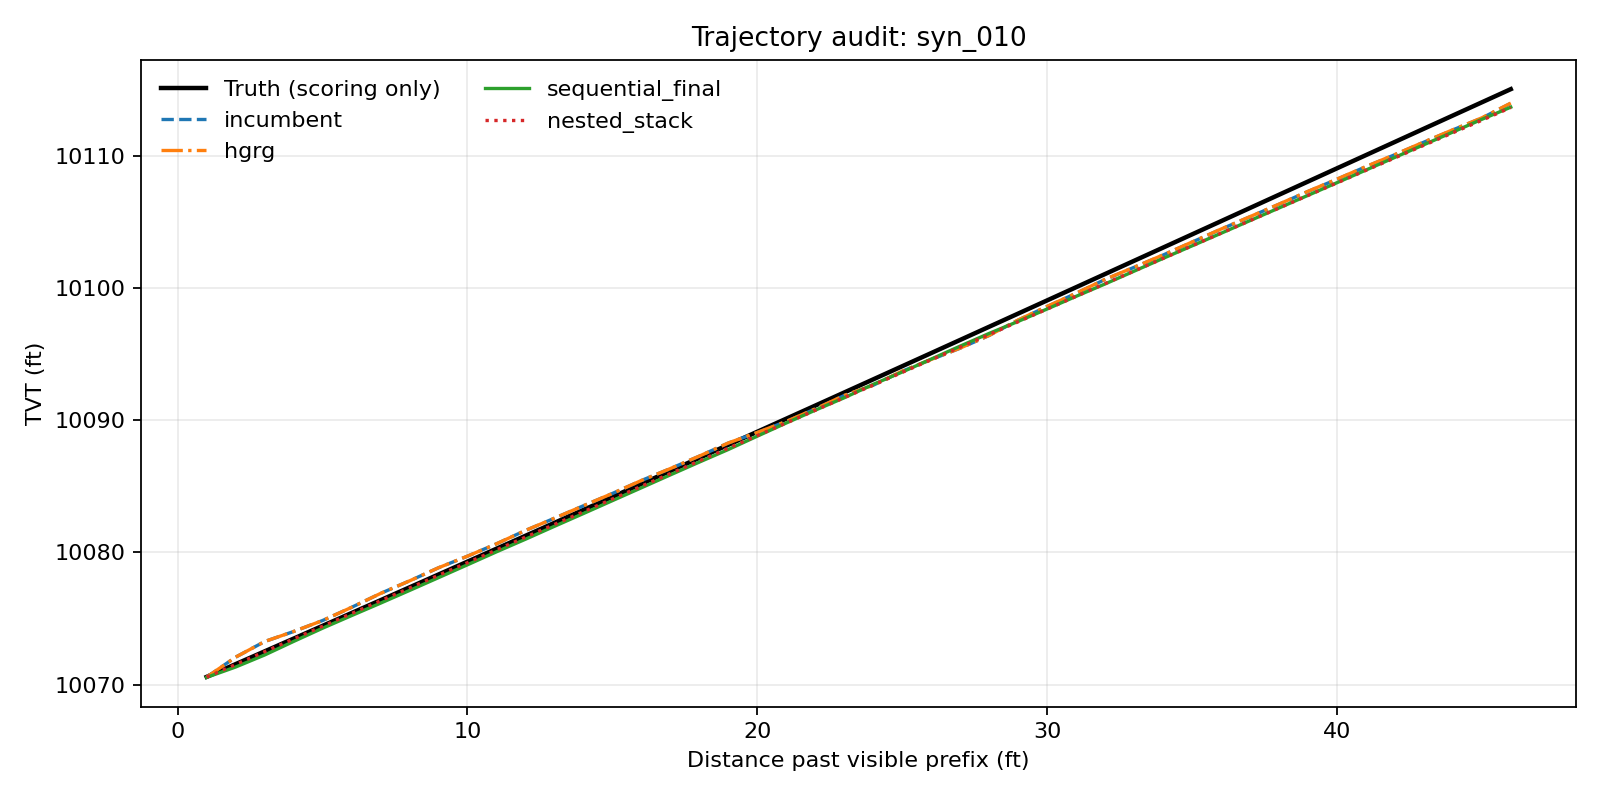

In [14]:
boot = summary["component_bootstrap"]
display(pd.DataFrame(boot).T)
display(Image(filename=str(ROOT / "evidence/example_trajectory.png")))


## 12. A tuning experiment that didn't transfer

I also ran a fully nested optimizer/epoch/decoder search. Different folds ended up picking high regularization, adaptive learning rate, modified Huber loss, label smoothing, structured transitions, 300 epochs, and a softened decoder. Despite all that tuning, the model actually got worse; 9.4531 to 9.4680; on its own Dev160 contract, improved on only 2 of 5 folds, hurt 85 of 160 wells, and had a component-bootstrap interval that crossed zero. It failed all four of my checks, so I stopped right there instead of opening the complementary labels.

The lesson wasn't that tuning is pointless. It was that these fold-specific optima had more variance than pooled benefit; more epochs weren't going to fix instability that was really about expert selection.

## 13. Where reproduction actually stands

| Reproduction check | Status |
|---|---|
| Clean-room algorithms and nested validation graph execute from source | **Yes: workflow + tests** |
| Historical 121 SAFE formulas execute from vendored source | **Yes: source hash + poison test** |
| Inference inputs->exact-order submission CSV graph executes | **Yes: deployment smoke** |
| Historical scored incumbent / Meta-State / Boundary are all byte-identical | **No** |
| One command rebuilds tracked smoke evidence, figures and notebook | **Yes** |
| Official raw data can replace the synthetic smoke data | **Yes, with `DATA_ROOT`** |
| Historical 9.091 `submission.csv` bytes reproduce without external artifacts | **No** |

Exact reproduction still hinges on the third-party Kaggle feature and pretrained-model packages the historical parent used. Those are listed in `configs/exact_artifacts.json`, and exact mode checks the real local files and their hashes. Retraining the reimplemented graph is genuinely useful, but it's a different experiment from reproducing the original bytes.

In [15]:
if deployment_audit:
    display(pd.DataFrame([{
        "status": deployment_audit["status"],
        "rows": deployment_audit["rows"],
        "truth in targets": deployment_audit["targets_contained_tvt"],
        "CSV SHA-256": deployment_audit["csv_sha256"],
    }]))


,status,rows,truth in targets,CSV SHA-256
0,PASS,92,False,12cfb386acf2d951eaace10b96c76c8cb2c6986263cbb4...


## 14. Looking back

The fixed final graph came out to 6.536 on the visible partition and 9.091 on the hidden one, sitting inside the displayed bronze-score band. Without matched hidden ablations, that's really just one observation of the full graph, not evidence for any single overlay. The run finished after the cutoff, so it wasn't eligible. I'd checked numerical correctness on a protected canary, but never runtime on a representative hidden workload; and in a code competition, the queue and hidden execution time need to be part of the experimental plan too, not an afterthought.

I also came out of this with a much longer math reading list than I expected going in. The particle filter sent me back to Bayesian filtering, GeoHMM to dynamic programming, Meta-State to generalized least squares and RTS smoothing, and the leakage split to graph theory. Signal processing and constrained optimization kept showing up too, any time I tried to separate wiggle from trend without moving a well too far. So the slightly embarrassing conclusion is probably true: I need to study more math; ideally before the next deadline, not while watching the submission queue.

In [16]:
required = [
    "particle.py", "geohmm.py", "features.py", "historical_features.py",
    "hgrg.py", "meta_state.py", "overlays.py", "stack.py", "pipeline.py",
    "deployment.py", "parents.py", "regret_router.py"
]
source_root = ROOT / "src/rogii_portfolio"
audit = pd.DataFrame([
    {"module": name, "exists": (source_root / name).exists(), "bytes": (source_root / name).stat().st_size}
    for name in required
])
display(audit)
assert audit["exists"].all()
assert len(SAFE_FEATURES) == 121
assert summary["target_isolation"]["component_overlap_count"] == 0
assert summary["target_isolation"]["suffix_truth_in_prediction_api"] is False
assert deployment_audit is None or deployment_audit["targets_contained_tvt"] is False
print("Notebook checks passed.")


,module,exists,bytes
0,particle.py,True,15851
1,geohmm.py,True,20981
2,features.py,True,11077
3,historical_features.py,True,27348
4,hgrg.py,True,2721
5,meta_state.py,True,4930
6,overlays.py,True,3006
7,stack.py,True,4149
8,pipeline.py,True,16563
9,deployment.py,True,5431


Notebook checks passed.
